In [1]:
from encoder_dataclass_cc import DataBaseConfig
from nilearn import image, plotting
import numpy as np
import nibabel as nib
import cortex
cortex.database.default_filestore
import matplotlib.pyplot as plt

In [2]:
!pwd

/home/ibilgin/Dropbox/language_encoder/src


# test image

/home/ibilgin/brain_encoding/ridge_regression/voxelwise/sub-03/s01//random.nii.gz
(71, 91, 71)


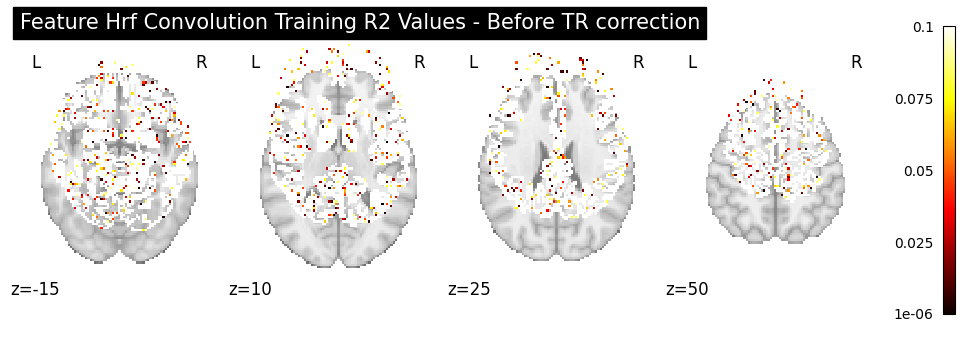

In [10]:
data_config = DataBaseConfig()

data_type = "val"
train_seasons = ["s01"]
val_season1 = ["s02"]
val_season2 = ["s04"]

layer_index = 1
data_config.subject_id = "sub-03"
data_config.encoding_level = "voxelwise"
output_dir= f"/home/ibilgin/brain_encoding/ridge_regression/{data_config.encoding_level}/{data_config.subject_id}/{train_seasons[0]}/"
# mean_img_name= f"{data_config.subject_id}_{val_season[0]}_mean_R2_{data_type}_layer_{layer_index}.nii.gz"

mean_img_name1 = f"random.nii.gz"
stat_img1 =f"{output_dir}/{mean_img_name1}"


print(stat_img1)
# print(image.load_img(stat_img).shape)
# vol_arr = np.swapaxes(nib.load(stat_img).get_fdata(), 0, -1)


# mean_img_name="sub-03_s04_mean_R2_layer_1.nii.gz"
# stat_img2 =f"{output_dir}/{mean_img_name}"
mean_img_name = mean_img_name1
vmin_value = 0  # minimum value of the color scale
vmax_value = 0.1  # maximum value of the color scale
s = "train"
cut_coords = [-15, 10, 25, 50]  # Specific coordinates in MNI space
print(image.load_img(stat_img1).shape)
plotting.plot_stat_map(
    stat_img1,
    display_mode='z',
    title="Feature Hrf Convolution Training R2 Values - Before TR correction",
    colorbar=True,
    vmin=vmin_value,  # Set minimum value of the color scale
    vmax=vmax_value,  # Set maximum value of the color scale#
    cmap="hot",
    cut_coords=cut_coords,

)


# Ridge Results Using Pearson R2

In [2]:
data_config = DataBaseConfig()

data_type = "val"
train_seasons = ["s01"]
val_season1 = ["s02"]
val_season2 = ["s04"]

layer_index = 1
data_config.subject_id = "sub-03"
data_config.encoding_level = "voxelwise"
output_dir= f"/home/ibilgin/brain_encoding/ridge_regression/{data_config.encoding_level}/{data_config.subject_id}/{train_seasons[0]}_r/mean_img"
# mean_img_name= f"{data_config.subject_id}_{val_season[0]}_mean_R2_{data_type}_layer_{layer_index}.nii.gz"

mean_img_name1 = f"{data_config.subject_id}_{val_season1[0]}_mean_R2_layer_1.nii.gz"
stat_img1 =f"{output_dir}/{mean_img_name1}"

mean_img_name2 = f"{data_config.subject_id}_{val_season2[0]}_mean_R2_layer_1.nii.gz"
stat_img2 =f"{output_dir}/{mean_img_name2}"

print(stat_img1)
# print(image.load_img(stat_img).shape)
# vol_arr = np.swapaxes(nib.load(stat_img).get_fdata(), 0, -1)


NameError: name 'DataBaseConfig' is not defined

(97, 115, 97)


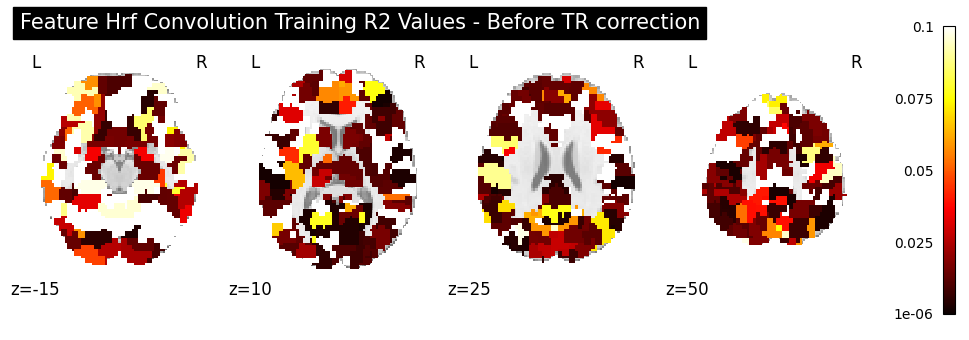

In [20]:
output_dir= f"/home/ibilgin/brain_encoding/ridge_regression/{data_config.encoding_level}/{data_config.subject_id}/{train_seasons[0]}/mean_img"

# mean_img_name="sub-03_s04_mean_R2_layer_1.nii.gz"
# stat_img2 =f"{output_dir}/{mean_img_name}"
mean_img_name = mean_img_name2
vmin_value = 0  # minimum value of the color scale
vmax_value = 0.1  # maximum value of the color scale
s = "train"
cut_coords = [-15, 10, 25, 50]  # Specific coordinates in MNI space
print(image.load_img(stat_img1).shape)
plotting.plot_stat_map(
    stat_img1,
    display_mode='z',
    title="Feature Hrf Convolution Training R2 Values - Before TR correction",
    colorbar=True,
    vmin=vmin_value,  # Set minimum value of the color scale
    vmax=vmax_value,  # Set maximum value of the color scale#
    cmap="hot",
    cut_coords=cut_coords,

)


/home/ibilgin/brain_encoding/ridge_regression/voxelwise/sub-03/s01/mean_img/sub-03_s02_mean_R2_layer_2.nii.gz
/home/ibilgin/brain_encoding/ridge_regression/voxelwise/sub-03/s01/mean_img/sub-03_s04_mean_R2_layer_2.nii.gz


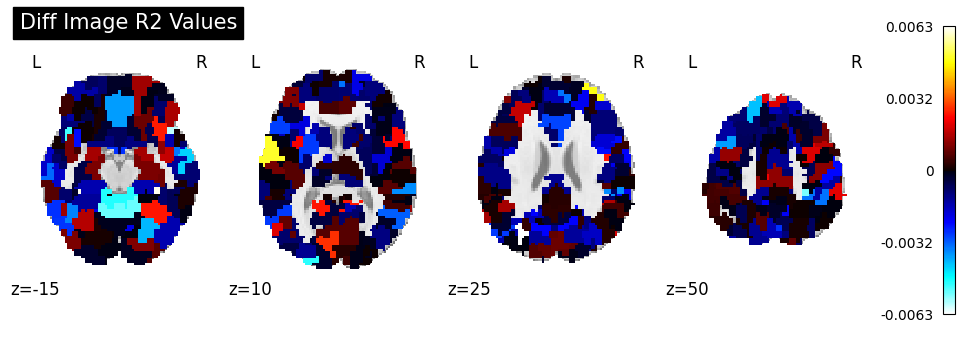

In [15]:
from  nilearn import image
# mean_img_name= "sub-03_s04_mean_R2_layer_1.nii.gz"
# stat_img1 =f"{output_dir}/{mean_img_name}"

print(stat_img1)
print(stat_img2)
diff_image = image.math_img("img1-img2",img1=stat_img1,img2=stat_img2 )

plotting.plot_stat_map(
    diff_image,
    display_mode='z',
    title="Diff Image R2 Values",
    colorbar=True,
    cmap="cold_hot",
    cut_coords=cut_coords,
)

# Ridge Results Using Mean Squared Error and Variance R2 - Native Space

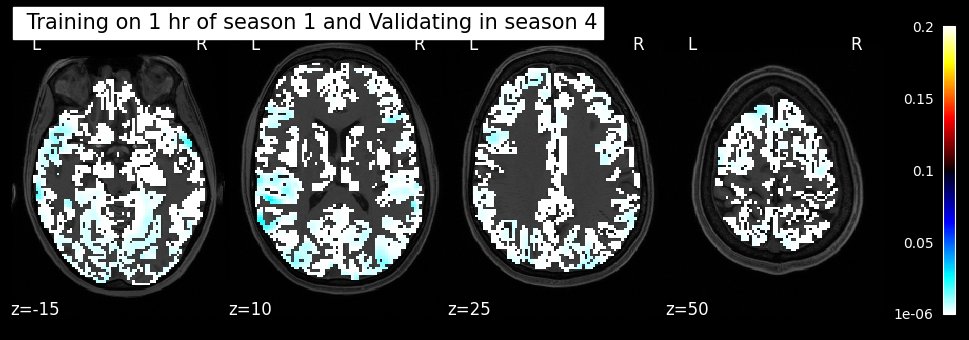

In [19]:
import nibabel as nib
data_type = "val"
train_seasons = ["s01"]
val_season1 = ["s05"]

layer_index = 1
data_config.subject_id = "sub-03"
data_config.encoding_level = "voxelwise"
output_dir= f"/home/ibilgin/brain_encoding/ridge_regression/{data_config.encoding_level}/{data_config.subject_id}/{train_seasons[0]}/mean_img"
t1w_img_path = "/home/ibilgin/brain_encoding/anatomical/sub-03_desc-preproc_T1w.nii.gz"

t1w_img = nib.load(t1w_img_path)

# Resample the statistical image to the T1w space

mean_img_name1 = f"{data_config.subject_id}_{val_season1[0]}_mean_R2_layer_1.nii.gz"
stat_img =nib.load(f"{output_dir}/{mean_img_name1}")


plotting.plot_stat_map(
    stat_img,
    bg_img=t1w_img,  # Use the T1w image as the background
    display_mode='z',
    title=" Training on 1 hr of season 1 and Validating in season 4",
    colorbar=True,
    vmin=vmin_value,  # Optional: set minimum value of the color scale
    vmax=vmax_value,  # Set maximum value of the color scale
    cmap="cold_hot",
    cut_coords=cut_coords,
)


# Pycortex plotting

In [4]:
surface = 'MNI'
xfm = 'atlas_152_sub1'
# get subject mask
mask = cortex.db.get_mask(surface , xfm , 'cortical')
mask.shape

(97, 115, 97)

In [5]:
R2 = nib.load(stat_img1).get_fdata().T
R2.shape


(71, 91, 71)

In [6]:
vol = cortex.Volume(R2, surface, xfm,
                    vmin = -0.4, vmax = 0.4, cmap = 'RdBu_r')


ValueError: Volumetric data (shape (71, 91, 71)) is not the same shape as reference for transform (shape (97, 115, 97))

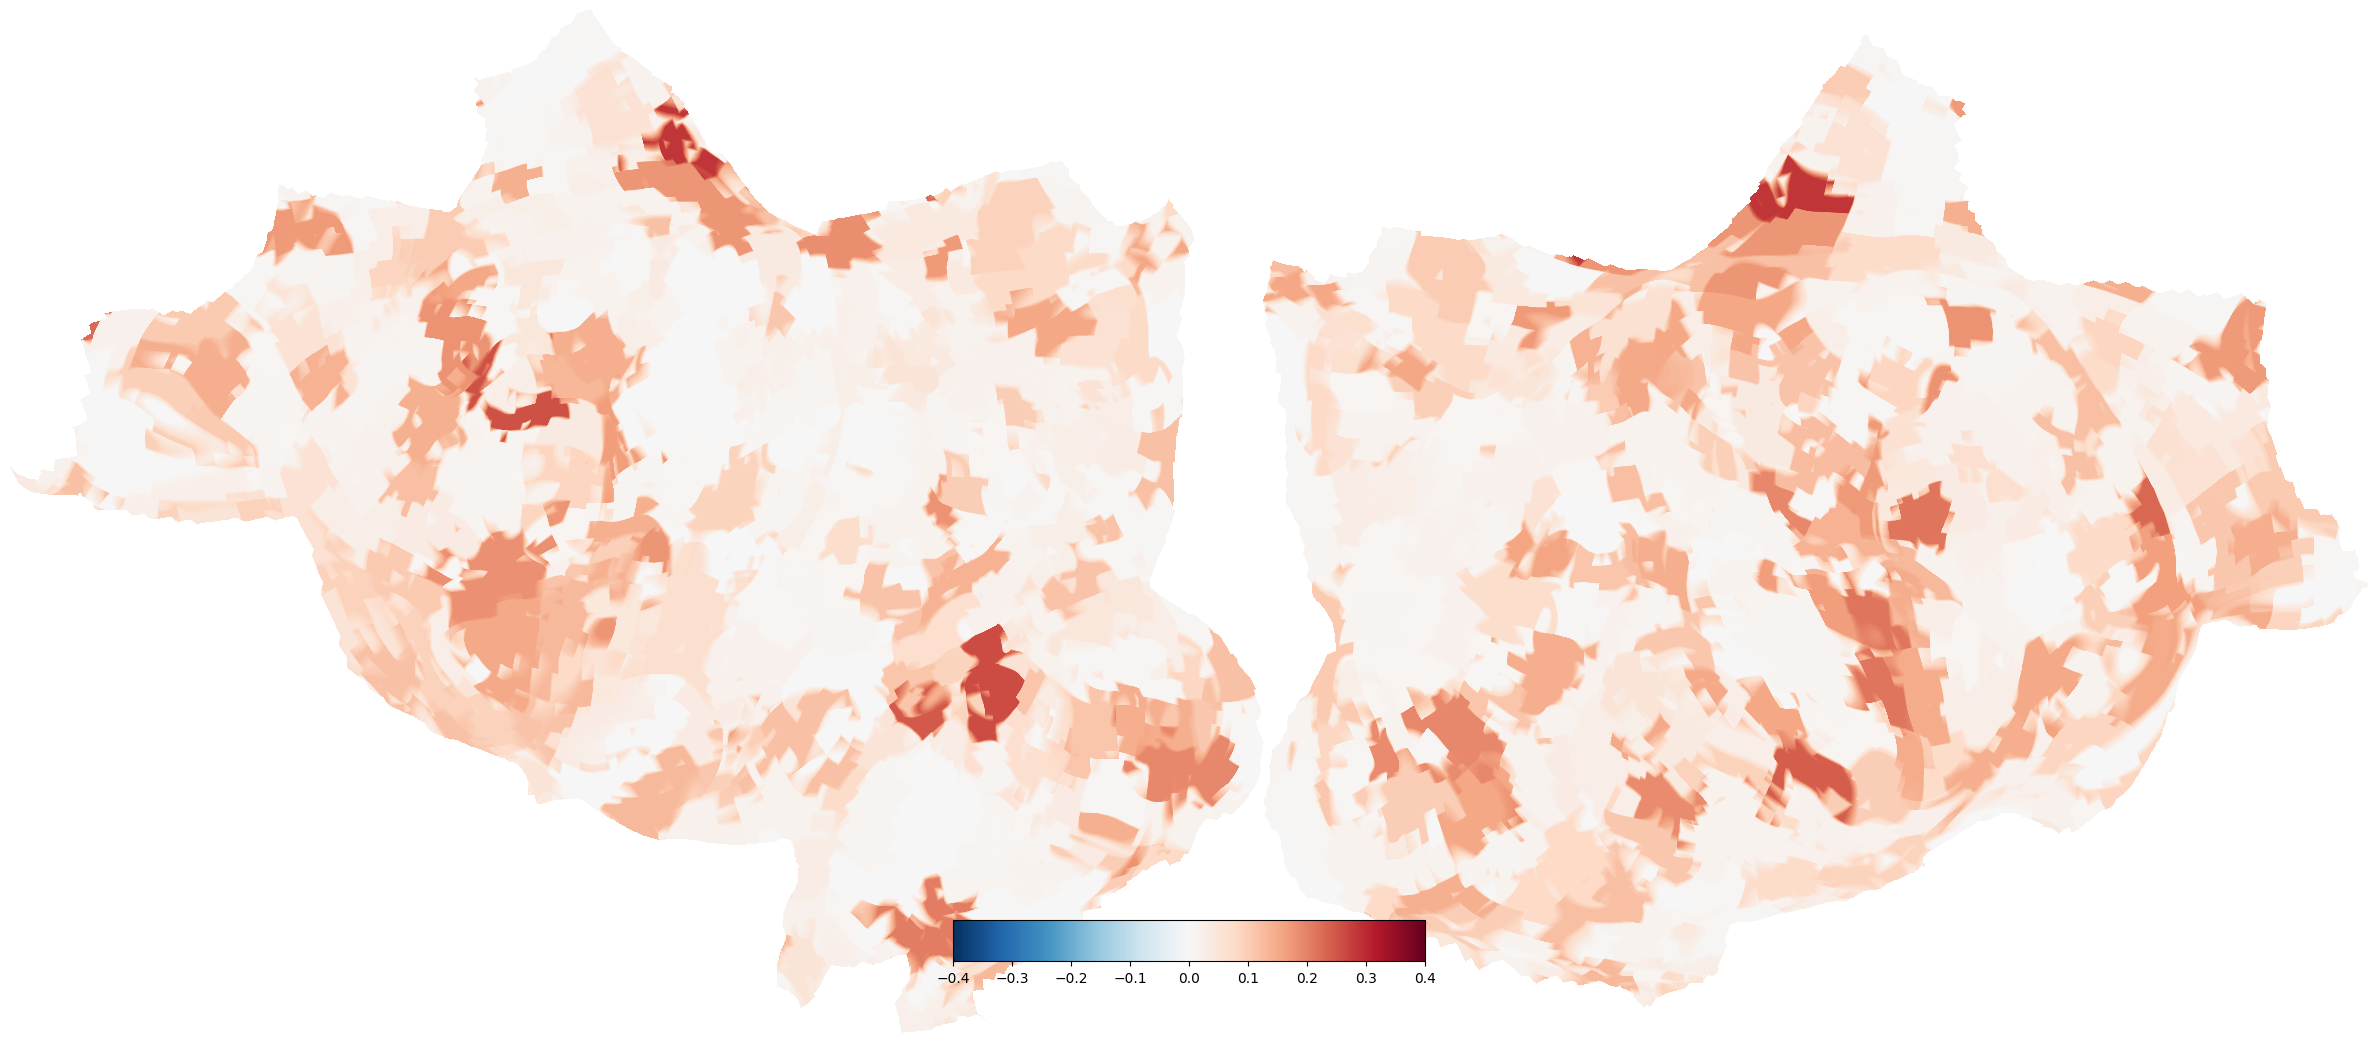

In [37]:
# now let's plot it on a flat map:
fig = cortex.quickflat.make_figure(vol, with_rois = False, title= f"{data_config.subject_id}_{val_season1[0]}_mean_R2_{data_type}_layer_{layer_index}")
# to see in interactive viewer (needs to be set up for remote)
# cortex.webshow(vol)


# cortex.webshow(vol)